In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
# Image size
IMG_SIZE = 128
BATCH_SIZE = 32

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
# Load training data
train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

Found 4249 images belonging to 2 classes.


In [5]:
# Validation data
val_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 472 images belonging to 2 classes.


In [6]:
# Load test data
test_generator = test_datagen.flow_from_directory(
    'data/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 550 images belonging to 2 classes.


In [7]:
# Build CNN model
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))  # Binary output

C:\Users\Anju\anaconda3\envs\copd\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 133s 968ms/step - accuracy: 0.8757 - loss: 0.3005 - val_accuracy: 0.9831 - val_loss: 0.0585
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 54s 408ms/step - accuracy: 0.9553 - loss: 0.1359 - val_accuracy: 0.9809 - val_loss: 0.0864
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 51s 385ms/step - accuracy: 0.9692 - loss: 0.1006 - val_accuracy: 0.9936 - val_loss: 0.0504
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 50s 375ms/step - accuracy: 0.9732 - loss: 0.0856 - val_accuracy: 0.9915 - val_loss: 0.0455
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 62s 469ms/step - accuracy: 0.9701 - loss: 0.0859 - val_accuracy: 0.9894 - val_loss: 0.0415
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - accuracy: 0.9739 - loss: 0.0787 - val_accuracy: 0.9936 - val_loss: 0.0366
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 33s 250ms/step - accuracy: 0.9748 - loss: 0.0694 - val_accuracy: 0.9873 - val_loss: 0.0319
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 32s 242ms/step - accuracy: 0.9779 - loss: 

In [10]:
model.save("cnn_model.h5")

In [11]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 279ms/step - accuracy: 0.9891 - loss: 0.0455
Test Accuracy: 0.9890909194946289


In [12]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9811720252037048
Final Validation Accuracy: 0.9957627058029175


In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Reset test generator
test_generator.reset()

# Get predictions
Y_pred = model.predict(test_generator)
y_pred = np.round(Y_pred).astype(int)

# True labels
y_true = test_generator.classes

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
Confusion Matrix:
[[244   6]
 [  0 300]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       250
           1       0.98      1.00      0.99       300

    accuracy                           0.99       550
   macro avg       0.99      0.99      0.99       550
weighted avg       0.99      0.99      0.99       550



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


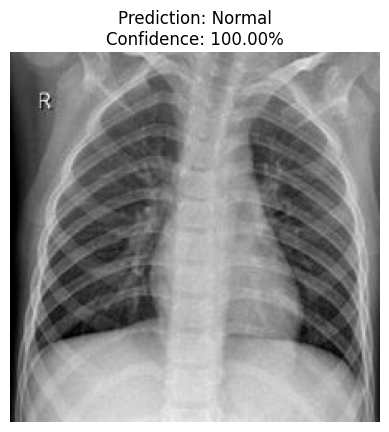

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load trained model
model = load_model("copd_cnn_model.h5")

img_path = r"data\train\Normal\Normal (20).jpg"

# Load image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Get class mapping
class_indices = train_generator.class_indices
labels = {v: k for k, v in class_indices.items()}

# Predict
prediction = model.predict(img_array)[0][0]

predicted_class = 1 if prediction > 0.5 else 0
label = labels[predicted_class]

confidence = prediction if prediction > 0.5 else 1 - prediction

# Show result
plt.imshow(image.load_img(img_path))
plt.title(f"Prediction: {label}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")
plt.show()